# Punto 2 — Estadística descriptiva univariada

## *"¿Cómo es cada segmento por dentro?"*

**Unidad III — Estadística Descriptiva · Diplomatura en Data Analytics (UNNE)**

Esta notebook acompaña el **video del Punto 2**. En el punto 1 aprendimos a desconfiar de
los datos. Ahora los vamos a resumir: convertir 20.640 filas en un puñado de números que
digan algo.

| Familia | Pregunta | Herramientas |
|---|---|---|
| **Tendencia central** | ¿Dónde está el centro? | media, mediana, moda |
| **Dispersión** | ¿Qué tan lejos del centro están los datos? | rango, varianza, desvío, CV |
| **Posición** | ¿Dónde cae un valor respecto del resto? | percentiles, cuartiles |

---
## 0 · Setup

In [1]:
import os
import sys

sys.path.append("../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

RUTA = "../data/raw/housing.csv"
URL = ("https://raw.githubusercontent.com/ageron/handson-ml2/"
       "master/datasets/housing/housing.csv")
df = pd.read_csv(RUTA) if os.path.exists(RUTA) else pd.read_csv(URL)

# Variable derivada del punto 1: total_rooms sólo se interpreta por hogar.
df["ambientes_por_hogar"] = df["total_rooms"] / df["households"]

VALOR = "median_house_value"     # la variable protagonista
GRUPO = "ocean_proximity"        # los segmentos que vamos a comparar

# Los colores del video, para que la notebook y las slides se vean igual.
# ISLAND va siempre en rojo: es el hilo narrativo de toda la unidad.
AZUL, ROJO, GRIS, AZUL_PALE = "#1E579B", "#D1495B", "#9AA5B1", "#DCEAF7"


def en_miles(v, _=None):
    """Formatea un eje en miles: 200000 -> 200k."""
    return f"{v/1_000:,.0f}k"


print(f"{df.shape[0]:,} filas × {df.shape[1]} columnas")

20,640 filas × 11 columnas


---
## 1 · Tendencia central: ¿dónde está el centro?

Tres formas de contestar "¿cuál es el valor típico?", y **no dan lo mismo**.

- **Media** — el promedio aritmético. Usa todos los datos, y por eso cualquier valor
  extremo la mueve.
- **Mediana** — el valor del medio cuando ordenás todo. La mitad queda abajo, la mitad
  arriba. No le importa cuán grandes son los extremos, sólo cuántos hay.
- **Moda** — el valor que más se repite. La única que sirve para variables categóricas.

In [2]:
x = df[VALOR]

print(f"n        = {x.count():,}")
print(f"media    = {x.mean():>10,.0f} USD")
print(f"mediana  = {x.median():>10,.0f} USD")
print(f"moda     = {x.mode().iloc[0]:>10,.0f} USD")
print()
print(f"La media es {x.mean()/x.median():.2f} veces la mediana.")
print(f"El {(x < x.mean()).mean():.1%} de los barrios está por debajo del 'promedio'.")

n        = 20,640
media    =    206,856 USD
mediana  =    179,700 USD
moda     =    500,001 USD

La media es 1.15 veces la mediana.
El 59.4% de los barrios está por debajo del 'promedio'.


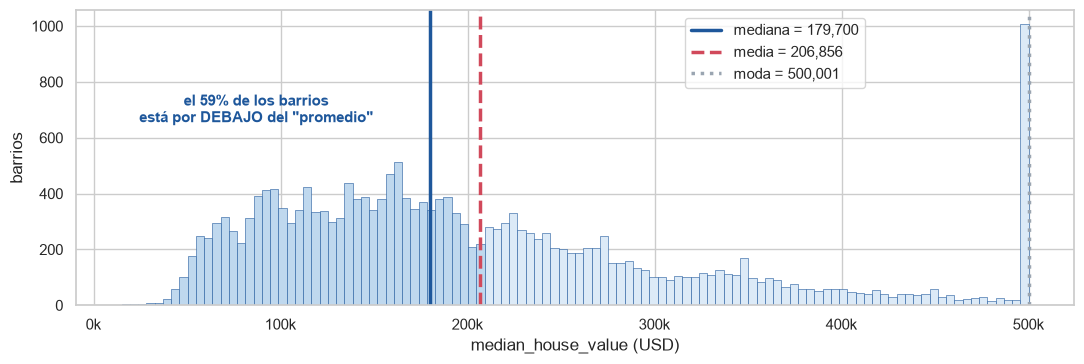

In [3]:
# Los tres centros, sobre la distribución que están tratando de resumir.
fig, ax = plt.subplots(figsize=(11, 3.8))
alturas, bordes, barras = ax.hist(x, bins=110, color=AZUL_PALE, edgecolor=AZUL, lw=0.4)
for barra, borde in zip(barras, bordes[:-1]):      # aclaramos lo que cae por debajo de la media
    if borde < x.mean():
        barra.set_facecolor("#BFD8EE")

ax.axvline(x.median(), color=AZUL, lw=2.5, label=f"mediana = {x.median():,.0f}")
ax.axvline(x.mean(), color=ROJO, lw=2.5, ls="--", label=f"media = {x.mean():,.0f}")
ax.axvline(x.mode().iloc[0], color=GRIS, lw=2.5, ls=":", label=f"moda = {x.mode().iloc[0]:,.0f}")
ax.text(x.mean() * 0.42, ax.get_ylim()[1] * 0.62,
        f'el {(x < x.mean()).mean():.0%} de los barrios\nestá por DEBAJO del "promedio"',
        ha="center", fontsize=11, color=AZUL, fontweight="bold")

ax.xaxis.set_major_formatter(en_miles)
ax.set_xlabel("median_house_value (USD)")
ax.set_ylabel("barrios")
ax.legend(loc="upper center", bbox_to_anchor=(0.70, 1.0))
plt.tight_layout()
plt.show()

La media queda un 15% arriba de la mediana y casi el 60% de los barrios está por debajo
del promedio. Hay una **cola hacia la derecha**: unos pocos barrios muy caros tiran de la
media, y por eso el "promedio" no es un valor típico.

Pero acá hay algo raro, y es lo primero que vamos a forzar.

#### ⚠️ Forzando el concepto (1): el tope te ocultó la asimetría

En el punto 1 vimos que `median_house_value` está **topeada en 500.001**, con 965 barrios
aplastados en ese valor. ¿Qué le hace un tope a la forma de la distribución?

In [4]:
# Comparemos la asimetría de nuestra variable topeada contra otras que NO lo están.
comparacion = pd.DataFrame({
    c: {
        "media": df[c].mean(),
        "mediana": df[c].median(),
        "ratio media/mediana": df[c].mean() / df[c].median(),
        "% por debajo de la media": (df[c] < df[c].mean()).mean() * 100,
        "asimetría (skew)": df[c].skew(),
    }
    for c in ["median_house_value", "total_rooms", "population", "households"]
}).T
comparacion.round(2)

,media,mediana,ratio media/mediana,% por debajo de la media,asimetría (skew)
median_house_value,206855.82,179700.0,1.15,59.38,0.98
total_rooms,2635.76,2127.0,1.24,64.45,4.15
population,1425.48,1166.0,1.22,63.60,4.94
households,499.54,409.0,1.22,63.76,3.41


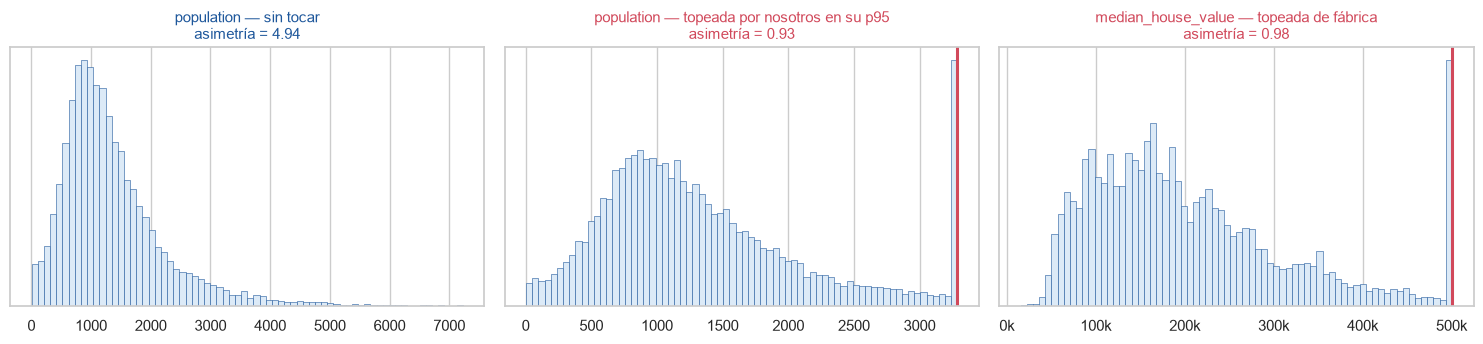

In [5]:
# El experimento: le hacemos a population lo mismo que le hicieron a nuestra variable.
pob = df["population"]
tope_p95 = pob.quantile(0.95)
pob_topeada = pob.clip(upper=tope_p95)

paneles = [
    (pob, pob.quantile(0.995), None, "population — sin tocar", AZUL),
    (pob_topeada, None, tope_p95, "population — topeada por nosotros en su p95", ROJO),
    (x, None, 500_001, "median_house_value — topeada de fábrica", ROJO),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (v, corte_visual, tope, titulo, color) in zip(axes, paneles):
    visible = v[v <= corte_visual] if corte_visual else v   # recorta el DIBUJO, no el cálculo
    ax.hist(visible, bins=70, color=AZUL_PALE, edgecolor=AZUL, lw=0.4)
    if tope:
        ax.axvline(tope, color=ROJO, lw=2.2)
    ax.set_title(f"{titulo}\nasimetría = {v.skew():.2f}", fontsize=11, color=color)
    ax.set_yticks([])

axes[2].xaxis.set_major_formatter(en_miles)
plt.tight_layout()
plt.show()

`median_house_value` tiene una asimetría de **0,98**. `population`, que mide algo parecido
en espíritu (una cantidad acumulada por barrio) y **no está topeada**, tiene **4,94**.

El tope **le cortó la cola a la distribución**. Los barrios que valían 800.000 o 1.200.000
fueron todos empujados a 500.001, así que la cola derecha desapareció y la variable *parece*
mucho más simétrica de lo que realmente es.

Y eso no es una interpretación: es lo que muestra el panel del medio. Le aplicamos a
`population` **el mismo tratamiento** —un tope arbitrario en su percentil 95— y su asimetría
se desplomó de **4,94 a 0,93**, prácticamente el 0,98 de nuestra variable. Una distribución
sana, topeada, se vuelve indistinguible de la nuestra.

> **Un problema de calidad no sólo cambia los números: cambia la FORMA.** Y la forma es
> justo lo que usamos para decidir si la media sirve o no. Si sólo mirabas la asimetría,
> el tope te habría convencido de que la media era una buena descripción.

#### ⚠️ Forzando el concepto (2): un solo dato mueve la media… ¿o no?

El caso clásico: agregamos **una fila inventada** y miramos cuánto se mueve cada medida.

In [6]:
# Un error de carga: alguien tipea 50.000.000 en vez de 500.000.
x_roto = pd.concat([x, pd.Series([50_000_000.0])], ignore_index=True)

tabla = pd.DataFrame({
    "original":    [x.mean(),      x.median(),      x.std()],
    "con 1 error": [x_roto.mean(), x_roto.median(), x_roto.std()],
}, index=["media", "mediana", "desvío"])
tabla["cambio %"] = (tabla["con 1 error"] / tabla["original"] - 1) * 100
tabla.round(2)

,original,con 1 error,cambio %
media,206855.82,209268.16,1.17
mediana,179700.00,179700.00,0.00
desvío,115395.62,365285.61,216.55


Resultado sorprendente: la media se movió **apenas un 1,2%**. El desvío, en cambio, se
disparó un **217%**.

¿Por qué la media casi no se movió? Porque **hay 20.640 filas**. Un dato entre veinte mil
pesa poco. La robustez de la media no es una propiedad fija: **depende de `n`**.

In [7]:
# Probemos el MISMO error sobre muestras de distinto tamaño.
np.random.seed(42)
filas = []
for n in [50, 200, 1_000, 5_000, 20_640]:
    sub = x.sample(n, random_state=42) if n < len(x) else x
    roto = pd.concat([sub, pd.Series([50_000_000.0])], ignore_index=True)
    filas.append({
        "n": n,
        "media original": sub.mean(),
        "media con el error": roto.mean(),
        "cambio % media": (roto.mean() / sub.mean() - 1) * 100,
        "cambio % mediana": (roto.median() / sub.median() - 1) * 100,
        "cambio % desvío": (roto.std() / sub.std() - 1) * 100,
    })
cambios = pd.DataFrame(filas).set_index("n")
cambios.round(2)

,media original,media con el error,cambio % media,cambio % mediana,cambio % desvío
n,,,,,
50,213558.04,1189762.78,457.11,2.49,5796.33
200,204155.03,451895.55,121.35,0.17,3070.37
1000,209696.55,259437.11,23.72,0.17,1255.32
5000,205902.76,215859.59,4.84,0.00,520.94
20640,206855.82,209268.16,1.17,0.00,216.55


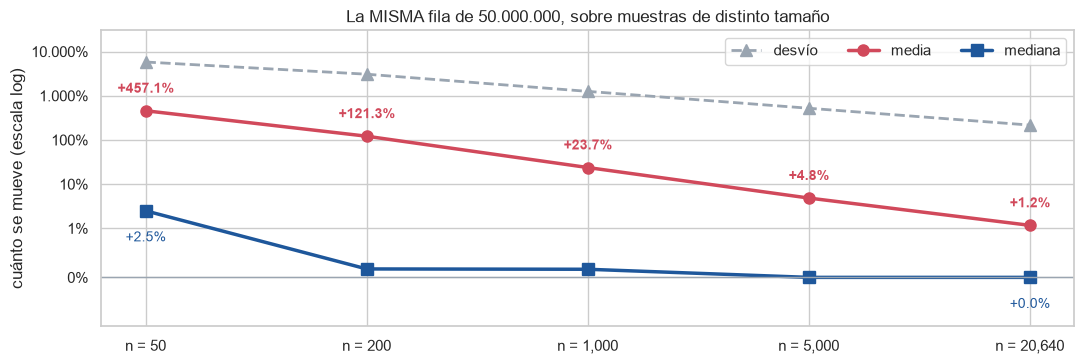

In [8]:
# La misma tabla, pero como curva: la fragilidad de la media es una función de n.
fig, ax = plt.subplots(figsize=(11, 3.8))
pos = range(len(cambios))
ax.set_yscale("symlog", linthresh=1)   # el desvío llega a +5.796%: en lineal aplasta todo lo demás

ax.plot(pos, cambios["cambio % desvío"], marker="^", ms=8, lw=2, ls="--", color=GRIS, label="desvío")
ax.plot(pos, cambios["cambio % media"], marker="o", ms=8, lw=2.5, color=ROJO, label="media")
ax.plot(pos, cambios["cambio % mediana"], marker="s", ms=8, lw=2.5, color=AZUL, label="mediana")

for i, v in enumerate(cambios["cambio % media"]):
    ax.annotate(f"+{v:,.1f}%", (i, v), textcoords="offset points", xytext=(0, 13),
                ha="center", fontsize=10, color=ROJO, fontweight="bold")
for i in (0, len(cambios) - 1):
    v = cambios["cambio % mediana"].iloc[i]
    ax.annotate(f"+{v:.1f}%", (i, v), textcoords="offset points", xytext=(0, -22),
                ha="center", fontsize=10, color=AZUL)

ax.axhline(0, color=GRIS, lw=1)
ax.set_ylim(-1, 30_000)
ax.set_yticks([0, 1, 10, 100, 1_000, 10_000])
ax.set_yticklabels(["0%", "1%", "10%", "100%", "1.000%", "10.000%"])
ax.set_xticks(list(pos))
ax.set_xticklabels([f"n = {n:,}" for n in cambios.index])
ax.set_ylabel("cuánto se mueve (escala log)")
ax.set_title("La MISMA fila de 50.000.000, sobre muestras de distinto tamaño")
ax.legend(ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

Con 50 filas, el mismo error único mueve la media más de un 400%. Con 20.640, un 1,2%. La
mediana no se mueve prácticamente en ningún caso.

> **Dos lecciones, no una.**
> 1. La **mediana es robusta** siempre: para moverla hay que cambiar la mitad de los datos.
> 2. La **media es frágil en muestras chicas** y bastante estable en muestras grandes. Si
>    trabajás con grupos de pocos casos —y en un rato vamos a ver uno de 5— la media es
>    exactamente donde te van a morder los errores.

#### ⚠️ Forzando el concepto (3): la moda en una variable continua

La moda es el valor más frecuente. En una variable continua eso **no debería existir**: si
medís con suficiente precisión, no hay dos valores iguales.

In [9]:
print("Valores más frecuentes de median_house_value:")
print(x.value_counts().head(4))
print()
print(f"valores distintos: {x.nunique():,} sobre {len(x):,} filas")

Valores más frecuentes de median_house_value:
median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
Name: count, dtype: int64

valores distintos: 3,842 sobre 20,640 filas


Y sin embargo la moda es **500.001, con 965 repeticiones**: exactamente el tope del punto 1.

Ese número no describe el mercado inmobiliario de California. Lo que hace es **delatar el
problema de calidad**.

> **Dónde sirve la moda:** en variables categóricas.
> **Dónde no sirve:** en continuas — salvo como detector de datos rellenados o topeados,
> que es justo para lo que la acabamos de usar.

In [10]:
# Acá la moda SÍ es la herramienta correcta: sobre una categórica.
print("Categoría más frecuente de ocean_proximity:", df[GRUPO].mode().iloc[0])
print()
print(df[GRUPO].value_counts())

Categoría más frecuente de ocean_proximity: <1H OCEAN

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


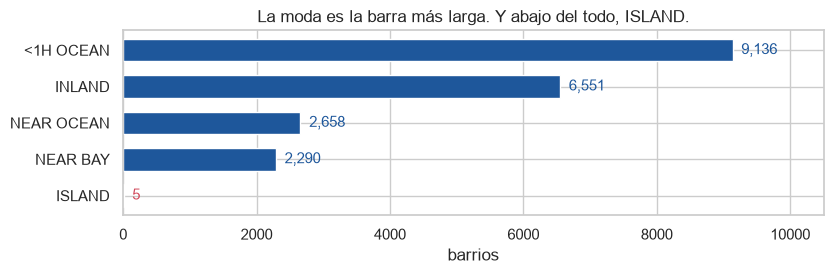

In [11]:
# Sobre una categórica la moda se lee de un vistazo: es la barra más larga.
conteo = df[GRUPO].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8.5, 2.9))
ax.barh(conteo.index, conteo.values, height=0.62,
        color=[ROJO if g == "ISLAND" else AZUL for g in conteo.index])
for i, (g, v) in enumerate(conteo.items()):
    ax.text(v + 130, i, f"{v:,}", va="center", fontsize=10.5,
            color=ROJO if g == "ISLAND" else AZUL)

ax.set_xlim(0, conteo.max() * 1.15)
ax.set_xlabel("barrios")
ax.set_title("La moda es la barra más larga. Y abajo del todo, ISLAND.")
plt.tight_layout()
plt.show()

---
## 2 · Dispersión: ¿qué tan lejos del centro están los datos?

Dos grupos pueden tener la misma media y ser completamente distintos.
`[49, 50, 51]` y `[0, 50, 100]` tienen media 50 y no se parecen en nada.

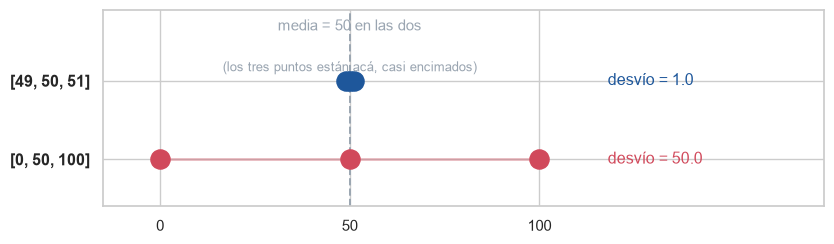

In [12]:
# Los dos ejemplos del párrafo de arriba, dibujados sobre el mismo eje.
fig, ax = plt.subplots(figsize=(8.5, 2.6))
for y, (serie, color) in zip([1, 0.5], [([49, 50, 51], AZUL), ([0, 50, 100], ROJO)]):
    ax.plot([min(serie), max(serie)], [y, y], color=color, lw=2, alpha=0.35)
    ax.scatter(serie, [y] * 3, s=190, color=color, zorder=3)
    ax.text(118, y, f"desvío = {np.std(serie, ddof=1):.1f}", fontsize=11.5, va="center", color=color)

ax.axvline(50, color=GRIS, ls="--", lw=1.4)
ax.text(50, 1.32, "media = 50 en las dos", ha="center", fontsize=11, color=GRIS)
ax.text(50, 1.06, "(los tres puntos están acá, casi encimados)", ha="center", fontsize=9, color=GRIS)

ax.set_xlim(-15, 175)
ax.set_ylim(0.2, 1.45)
ax.set_yticks([1, 0.5])
ax.set_yticklabels(["[49, 50, 51]", "[0, 50, 100]"], fontsize=11.5, fontweight="bold")
ax.set_xticks([0, 50, 100])
plt.tight_layout()
plt.show()

### 2.1 · Rango — la más simple, y la más frágil

In [13]:
print(f"rango = {x.max():,.0f} - {x.min():,.0f} = {x.max() - x.min():,.0f}")
print()
print("El rango usa exactamente DOS datos de los 20.640: el mayor y el menor.")
print("Y acá el mayor ni siquiera es un dato real: es el tope.")

rango = 500,001 - 14,999 = 485,002

El rango usa exactamente DOS datos de los 20.640: el mayor y el menor.
Y acá el mayor ni siquiera es un dato real: es el tope.


### 2.2 · Varianza y desvío estándar

La idea, en una frase: **el promedio de las distancias al cuadrado respecto de la media**.

¿Por qué al cuadrado? Porque si sumáramos las distancias tal cual, las de arriba y las de
abajo se cancelarían y siempre daría cero.

In [14]:
valores = x.dropna().to_numpy()
n = len(valores)

media = valores.sum() / n                    # paso 1: el centro
desvios = valores - media                    # paso 2: distancia de cada dato al centro
cuadrados = desvios ** 2                     # paso 3: al cuadrado, para que no se cancelen

var_muestral    = cuadrados.sum() / (n - 1)  # paso 4a: dividiendo por n-1
var_poblacional = cuadrados.sum() / n        # paso 4b: dividiendo por n

print(f"suma de los desvíos SIN elevar al cuadrado: {desvios.sum():.6f}   ← siempre ~0")
print()
print(f"varianza muestral    (÷ n-1) = {var_muestral:>18,.0f}   [USD²]")
print(f"varianza poblacional (÷ n)   = {var_poblacional:>18,.0f}   [USD²]")
print(f"desvío estándar = √varianza  = {np.sqrt(var_muestral):>18,.0f}   [USD]")
print()
print("La varianza está en unidades AL CUADRADO: 'dólares al cuadrado' no")
print("significa nada. Por eso reportamos el desvío, que vuelve a las unidades")
print("originales y se puede comparar con la media.")

suma de los desvíos SIN elevar al cuadrado: -0.000000   ← siempre ~0

varianza muestral    (÷ n-1) =     13,316,148,163   [USD²]
varianza poblacional (÷ n)   =     13,315,503,001   [USD²]
desvío estándar = √varianza  =            115,396   [USD]

La varianza está en unidades AL CUADRADO: 'dólares al cuadrado' no
significa nada. Por eso reportamos el desvío, que vuelve a las unidades
originales y se puede comparar con la media.


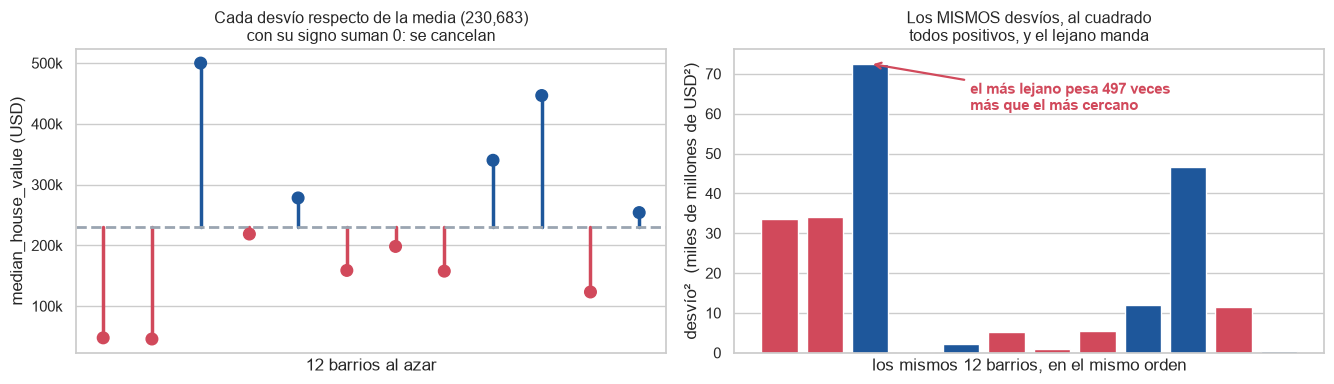

In [15]:
# Los pasos 2 y 3, dibujados sobre 12 barrios (con 20.640 no se vería nada).
muestra = x.sample(12, random_state=42).to_numpy()
centro = muestra.mean()
d = muestra - centro
colores = [AZUL if dv > 0 else ROJO for dv in d]      # azul: por encima. rojo: por debajo.

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4))

for i, v in enumerate(muestra):                       # paso 2: la distancia de cada dato al centro
    a1.plot([i, i], [centro, v], color=colores[i], lw=2.5)
a1.scatter(range(12), muestra, s=70, color=colores, zorder=3)
a1.axhline(centro, color=GRIS, lw=2, ls="--")
a1.yaxis.set_major_formatter(en_miles)
a1.set_title(f"Cada desvío respecto de la media ({centro:,.0f})\n"
             f"con su signo suman {d.sum():,.0f}: se cancelan", fontsize=11.5)
a1.set_xlabel("12 barrios al azar")
a1.set_ylabel("median_house_value (USD)")
a1.set_xticks([])

a2.bar(range(12), d ** 2 / 1e9, color=colores)        # paso 3: los mismos desvíos, al cuadrado
a2.set_title("Los MISMOS desvíos, al cuadrado\ntodos positivos, y el lejano manda", fontsize=11.5)
a2.set_xlabel("los mismos 12 barrios, en el mismo orden")
a2.set_ylabel("desvío²  (miles de millones de USD²)")
a2.set_xticks([])
mayor, menor = (d ** 2).max(), (d ** 2).min()
a2.annotate(f"el más lejano pesa {mayor/menor:,.0f} veces\nmás que el más cercano",
            xy=(int(np.argmax(d ** 2)), mayor / 1e9),
            xytext=(0.40, 0.80), textcoords="axes fraction", fontsize=10.5, color=ROJO,
            fontweight="bold", arrowprops=dict(arrowstyle="->", color=ROJO, lw=1.6))

plt.tight_layout()
plt.show()

#### ⚠️ Forzando el concepto: ¿por qué n − 1? ¿y cuándo importa?

Al medir distancias respecto de la media **de la muestra** —que es, por construcción, el
punto más cercano posible a esos datos— subestimamos la dispersión real de la población.
Dividir por `n − 1` corrige ese sesgo.

La pregunta honesta es: **¿cuánto cambia en la práctica?**

In [16]:
filas = []
for tam in [3, 5, 10, 30, 100, 1_000, len(valores)]:
    sub = valores[:tam]
    sc = ((sub - sub.mean()) ** 2).sum()
    filas.append({
        "n": tam,
        "÷ (n-1)": sc / (tam - 1),
        "÷ n": sc / tam,
        "diferencia %": ((sc / (tam - 1)) / (sc / tam) - 1) * 100,
    })
pd.DataFrame(filas).set_index("n").round(2)

,÷ (n-1),÷ n,diferencia %
n,,,
3,3.166003e+09,2.110669e+09,50.00
5,2.217443e+09,1.773954e+09,25.00
10,4.672448e+09,4.205204e+09,11.11
30,9.001504e+09,8.701454e+09,3.45
100,6.357812e+09,6.294234e+09,1.01
1000,7.927738e+09,7.919810e+09,0.10
20640,1.331615e+10,1.331550e+10,0.00


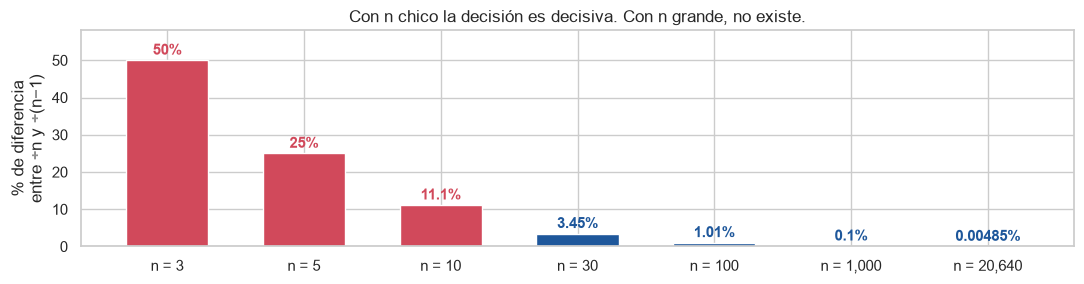

In [17]:
# La última columna de la tabla, dibujada: la diferencia se desploma con n.
tam = [3, 5, 10, 30, 100, 1_000, len(valores)]
dif = [(t / (t - 1) - 1) * 100 for t in tam]

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(range(len(tam)), dif, width=0.6, color=[ROJO if d > 5 else AZUL for d in dif])
for i, d in enumerate(dif):
    ax.text(i, d + 1.5, f"{d:.3g}%", ha="center", fontsize=10.5,
            color=ROJO if d > 5 else AZUL, fontweight="bold")

ax.set_xticks(range(len(tam)))
ax.set_xticklabels([f"n = {t:,}" for t in tam])
ax.set_ylim(0, 58)
ax.set_ylabel("% de diferencia\nentre ÷n y ÷(n−1)")
ax.set_title("Con n chico la decisión es decisiva. Con n grande, no existe.")
plt.tight_layout()
plt.show()

La diferencia es exactamente `n / (n−1) − 1`:

- con **n = 3** → 50%. Enorme.
- con **n = 30** → 3,4%.
- con **n = 20.640** → 0,005%. Irrelevante.

> **La conclusión práctica:** con muestras grandes la discusión `n` vs `n−1` no vale la
> pena. Con muestras chicas es decisiva. Y "muestra chica" es exactamente el escenario que
> nos va a complicar la vida en el punto 5.

*Ojo con una confusión clásica:* `pandas` usa `n−1` por defecto en `.var()` y `.std()`;
`numpy` usa `n` en `np.var()` y `np.std()`. Si comparás resultados con un compañero y no
coinciden, empezá por ahí.

### 2.3 · Coeficiente de variación: comparar peras con manzanas

El desvío está en las unidades de la variable, así que **no sirve para comparar grupos de
escalas distintas**. El coeficiente de variación lo arregla dividiendo por la media:

$$CV = \frac{\text{desvío}}{\text{media}}$$

In [18]:
tabla = df.groupby(GRUPO)[VALOR].agg(["count", "mean", "median", "std"])
tabla["cv"] = tabla["std"] / tabla["mean"]
tabla.sort_values("mean", ascending=False).round(3)

,count,mean,median,std,cv
ocean_proximity,,,,,
ISLAND,5,380440.000,414700.0,80559.562,0.212
NEAR BAY,2290,259212.312,233800.0,122818.537,0.474
NEAR OCEAN,2658,249433.977,229450.0,122477.146,0.491
<1H OCEAN,9136,240084.285,214850.0,106124.292,0.442
INLAND,6551,124805.392,108500.0,70007.908,0.561


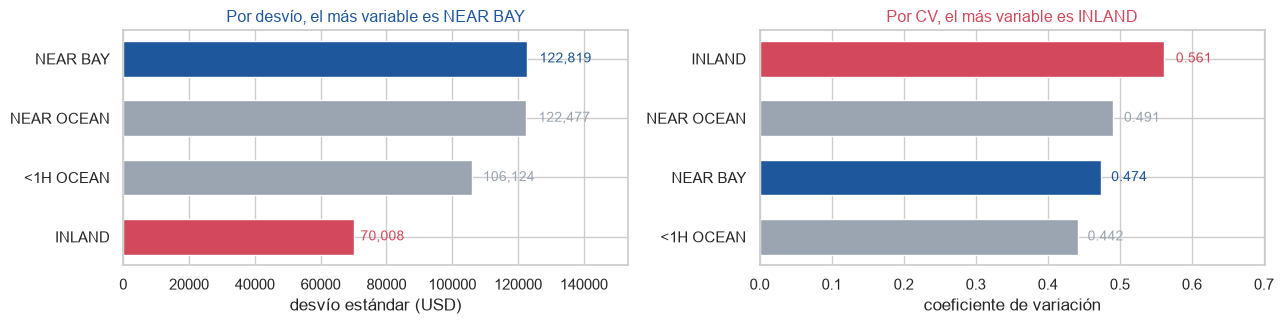

In [19]:
# Las dos últimas columnas, una al lado de la otra. Sacamos ISLAND: con n=5 distorsiona todo.
por_grupo = tabla.drop("ISLAND")

# Los dos protagonistas van con color fijo en LOS DOS paneles, para poder seguirlos.
resaltar = {"NEAR BAY": AZUL, "INLAND": ROJO}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.4))
for ax, col, etiqueta, titulo in [
        (a1, "std", "desvío estándar (USD)", "Por desvío, el más variable es NEAR BAY"),
        (a2, "cv", "coeficiente de variación", "Por CV, el más variable es INLAND")]:
    o = por_grupo.sort_values(col)
    ax.barh(o.index, o[col], height=0.6, color=[resaltar.get(g, GRIS) for g in o.index])
    for i, (g, fila) in enumerate(o.iterrows()):
        texto = f"{fila[col]:,.0f}" if col == "std" else f"{fila[col]:.3f}"
        ax.text(fila[col] * 1.03, i, texto, va="center", fontsize=10, color=resaltar.get(g, GRIS))
    ax.set_xlim(0, o[col].max() * 1.25)
    ax.set_xlabel(etiqueta)
    ax.set_ylabel("")
    ax.set_title(titulo, fontsize=11.5, color=AZUL if col == "std" else ROJO)

plt.tight_layout()
plt.show()

Leé las dos últimas columnas con atención, porque **ordenan los grupos al revés**:

| | desvío | CV |
|---|---|---|
| **NEAR BAY** | **122.819** ← el más alto (sin contar ISLAND) | 0,474 |
| **INLAND** | **70.008** ← el más bajo | **0,561** ← el más alto |

- Según el **desvío**, los barrios de la bahía son los más variables.
- Según el **CV**, los de tierra adentro lo son.

**Las dos lecturas son correctas, sobre preguntas distintas.** `NEAR BAY` se mueve en casi
el doble de dólares que `INLAND` — pero también maneja valores que son el doble de altos.
En proporción a lo que vale una casa ahí, `INLAND` es bastante más impredecible.

Si tuvieras que decidir en qué zona es más difícil estimar el precio de una propiedad sin
verla, el desvío te confunde y el CV te contesta.

#### ⚠️ Forzando el concepto: el CV más bajo es el del grupo con 5 datos

Mirá otra vez la tabla completa. **`ISLAND` tiene el CV más bajo de todos: 0,212.**

In [20]:
isla = df[df[GRUPO] == "ISLAND"][[VALOR, "housing_median_age", "population"]]
print(f"Todas las filas de ISLAND (n = {len(isla)}):\n")
print(isla.to_string())
print()
print(f"media = {isla[VALOR].mean():,.0f}   desvío = {isla[VALOR].std():,.0f}"
      f"   CV = {isla[VALOR].std()/isla[VALOR].mean():.3f}")

Todas las filas de ISLAND (n = 5):

      median_house_value  housing_median_age  population
8314            450000.0                27.0       744.0
8315            414700.0                52.0      1100.0
8316            300000.0                52.0       733.0
8317            450000.0                52.0       341.0
8318            287500.0                29.0       422.0

media = 380,440   desvío = 80,560   CV = 0.212


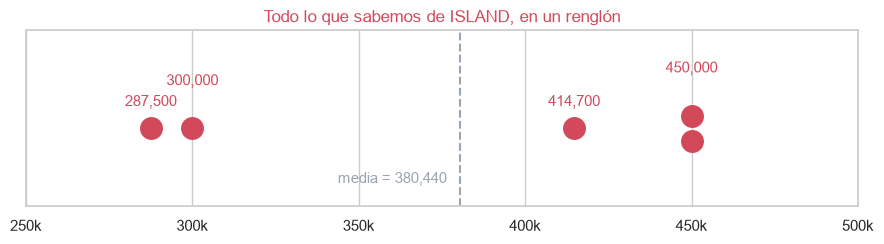

In [21]:
# Todo el grupo ISLAND cabe en un renglón. Los dos barrios de 450.000 van apilados.
repetidos = isla[VALOR].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 2.6))
for i, (v, veces) in enumerate(repetidos.items()):
    alturas_y = [1 + (k - (veces - 1) / 2) * 0.13 for k in range(veces)]
    ax.scatter([v] * veces, alturas_y, s=240, color=ROJO, zorder=3)
    ax.annotate(f"{v:,.0f}", (v, max(alturas_y)), textcoords="offset points",
                xytext=(0, 16 + (i % 2) * 15), ha="center", fontsize=10.5, color=ROJO)

ax.axvline(isla[VALOR].mean(), color=GRIS, ls="--", lw=1.5)
ax.text(isla[VALOR].mean() - 4_000, 0.72, f"media = {isla[VALOR].mean():,.0f}",
        ha="right", fontsize=11, color=GRIS)

ax.xaxis.set_major_formatter(en_miles)
ax.set_xlim(250_000, 500_000)
ax.set_ylim(0.6, 1.5)
ax.set_yticks([])
ax.set_title("Todo lo que sabemos de ISLAND, en un renglón", color=ROJO, fontsize=12)
plt.tight_layout()
plt.show()

¿Las casas en islas son las más caras **y** las más previsibles de California?

Con **cinco** barrios no lo podemos afirmar. Un CV bajo calculado sobre 5 datos no dice que
el grupo sea homogéneo: dice que **esos cinco** se parecen entre sí. Con tan pocos casos,
cualquier medida de dispersión es en sí misma muy variable.

> Esta es la tensión que atraviesa toda la unidad y que se resuelve recién en el punto 5:
> **un número calculado sobre pocos datos no es más confiable por ser más chico o más
> prolijo.**

> **Y un límite del CV que conviene saber:** divide por la media, así que se rompe si la
> media es cero o si la variable tiene valores negativos (la media queda cerca de cero y el
> CV explota). Usalo sólo en variables **positivas y con cero absoluto** — precios,
> cantidades, distancias. Nunca en variaciones porcentuales ni en temperaturas.

---
## 3 · Posición: ¿dónde cae un valor respecto del resto?

Un **percentil** parte los datos ordenados. El percentil 25 deja al 25% por debajo. Los
**cuartiles** son los percentiles 25, 50 y 75. La mediana y el percentil 50 son lo mismo.

In [22]:
q1, q2, q3 = np.percentile(valores, [25, 50, 75])
iqr = q3 - q1

print(f"mínimo        {valores.min():>10,.0f}")
print(f"Q1  (p25)     {q1:>10,.0f}   ← el 25% de los barrios vale menos que esto")
print(f"Q2  (mediana) {q2:>10,.0f}")
print(f"Q3  (p75)     {q3:>10,.0f}")
print(f"máximo        {valores.max():>10,.0f}   ← el tope, no un valor real")
print()
print(f"IQR = Q3 - Q1 = {iqr:,.0f}   ← el 50% del medio cabe en este rango")

mínimo            14,999
Q1  (p25)        119,600   ← el 25% de los barrios vale menos que esto
Q2  (mediana)    179,700
Q3  (p75)        264,725
máximo           500,001   ← el tope, no un valor real

IQR = Q3 - Q1 = 145,125   ← el 50% del medio cabe en este rango


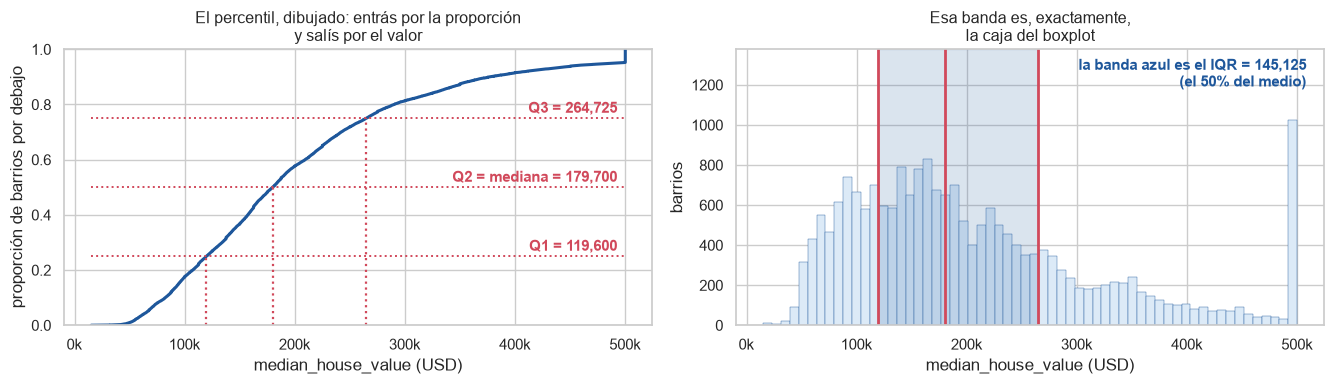

In [23]:
# Un percentil es una operación geométrica: conviene verla.
orden_v = np.sort(valores)
prop = np.arange(1, len(orden_v) + 1) / len(orden_v)   # qué proporción queda por debajo de cada valor

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4))

a1.plot(orden_v, prop, color=AZUL, lw=2.2)
for q, p, etiqueta in [(q1, 0.25, "Q1"), (q2, 0.50, "Q2 = mediana"), (q3, 0.75, "Q3")]:
    a1.plot([orden_v.min(), orden_v.max()], [p, p], color=ROJO, ls=":", lw=1.4)  # entrás por acá
    a1.plot([q, q], [0, p], color=ROJO, ls=":", lw=1.6)                          # y salís por acá
    a1.text(orden_v.max(), p + 0.02, f"{etiqueta} = {q:,.0f}  ", ha="right",
            fontsize=10.5, color=ROJO, fontweight="bold")
a1.xaxis.set_major_formatter(en_miles)
a1.set_title("El percentil, dibujado: entrás por la proporción\ny salís por el valor", fontsize=11.5)
a1.set_xlabel("median_house_value (USD)")
a1.set_ylabel("proporción de barrios por debajo")
a1.set_ylim(0, 1)

a2.hist(valores, bins=60, color=AZUL_PALE, edgecolor=AZUL, lw=0.3)
a2.axvspan(q1, q3, color=AZUL, alpha=0.16)
for q in (q1, q2, q3):
    a2.axvline(q, color=ROJO, lw=2)
a2.set_ylim(0, a2.get_ylim()[1] * 1.28)
a2.text(0.97, 0.97, f"la banda azul es el IQR = {iqr:,.0f}\n(el 50% del medio)",
        transform=a2.transAxes, ha="right", va="top", fontsize=11, color=AZUL, fontweight="bold")
a2.xaxis.set_major_formatter(en_miles)
a2.set_title("Esa banda es, exactamente,\nla caja del boxplot", fontsize=11.5)
a2.set_xlabel("median_house_value (USD)")
a2.set_ylabel("barrios")

plt.tight_layout()
plt.show()

#### ⚠️ Forzando el concepto: con pocos datos, "el percentil 25" es ambiguo

Con 20.640 datos el percentil 25 está bien definido. Con 4 datos, ¿cuál es el valor que
deja "el 25% por debajo"? Ninguno lo hace exactamente, así que hay que **interpolar** — y
hay varias formas válidas de hacerlo.

In [24]:
chico = np.array([10.0, 20.0, 30.0, 40.0])
print("Datos:", chico, "\n")
print("Percentil 25 según el método de interpolación:")
for metodo in ["linear", "lower", "higher", "nearest", "midpoint"]:
    print(f"   {metodo:>10}: {np.percentile(chico, 25, method=metodo):6.2f}")
print("\nCinco respuestas distintas, todas defendibles, para la misma pregunta.")

Datos: [10. 20. 30. 40.] 

Percentil 25 según el método de interpolación:
       linear:  17.50
        lower:  10.00
       higher:  20.00
      nearest:  20.00
     midpoint:  15.00

Cinco respuestas distintas, todas defendibles, para la misma pregunta.


In [25]:
print("Percentil 25 de median_house_value (n = 20.640):")
for metodo in ["linear", "lower", "higher", "nearest", "midpoint"]:
    print(f"   {metodo:>10}: {np.percentile(valores, 25, method=metodo):>10,.2f}")
print("\nPrácticamente idénticos. La ambigüedad es un problema de n chico,")
print("no de la herramienta.")

Percentil 25 de median_house_value (n = 20.640):
       linear: 119,600.00
        lower: 119,600.00
       higher: 119,600.00
      nearest: 119,600.00
     midpoint: 119,600.00

Prácticamente idénticos. La ambigüedad es un problema de n chico,
no de la herramienta.


---
## 4 · Distribución de frecuencias y forma

Los números resumen; los gráficos muestran **la forma**. Y la forma es la que te dice si
los números que calculaste describen bien a los datos.

### 4.1 · Tabla de frecuencias

In [26]:
tramos = pd.cut(x, bins=[0, 100_000, 150_000, 200_000, 300_000, 400_000, 500_002])

frecuencias = pd.DataFrame({"frecuencia": tramos.value_counts().sort_index()})
frecuencias["%"] = (frecuencias["frecuencia"] / len(x) * 100).round(1)
frecuencias["% acumulado"] = frecuencias["%"].cumsum().round(1)
frecuencias

,frecuencia,%,% acumulado
median_house_value,,,
"(0, 100000]",3658,17.7,17.7
"(100000, 150000]",3962,19.2,36.9
"(150000, 200000]",4311,20.9,57.8
"(200000, 300000]",4873,23.6,81.4
"(300000, 400000]",2092,10.1,91.5
"(400000, 500002]",1744,8.4,99.9


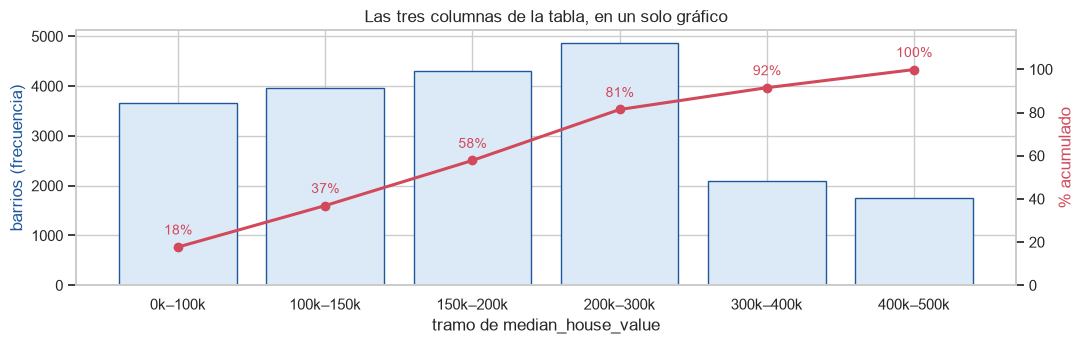

In [27]:
# La misma tabla, dibujada: barras para la frecuencia, línea para el acumulado.
etiquetas = [f"{int(i.left/1000)}k–{int(i.right/1000)}k" for i in frecuencias.index]

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(etiquetas, frecuencias["frecuencia"], color=AZUL_PALE, edgecolor=AZUL, lw=1)
ax.set_ylabel("barrios (frecuencia)", color=AZUL)
ax.set_xlabel("tramo de median_house_value")

ax2 = ax.twinx()                      # segundo eje: el acumulado va en %, no en barrios
ax2.plot(etiquetas, frecuencias["% acumulado"], color=ROJO, marker="o", lw=2.2)
for e, v in zip(etiquetas, frecuencias["% acumulado"]):
    ax2.annotate(f"{v:.0f}%", (e, v), textcoords="offset points", xytext=(0, 9),
                 ha="center", fontsize=10, color=ROJO)
ax2.set_ylabel("% acumulado", color=ROJO)
ax2.set_ylim(0, 118)
ax2.grid(False)

ax.set_title("Las tres columnas de la tabla, en un solo gráfico")
plt.tight_layout()
plt.show()

### 4.2 · Histograma y boxplot

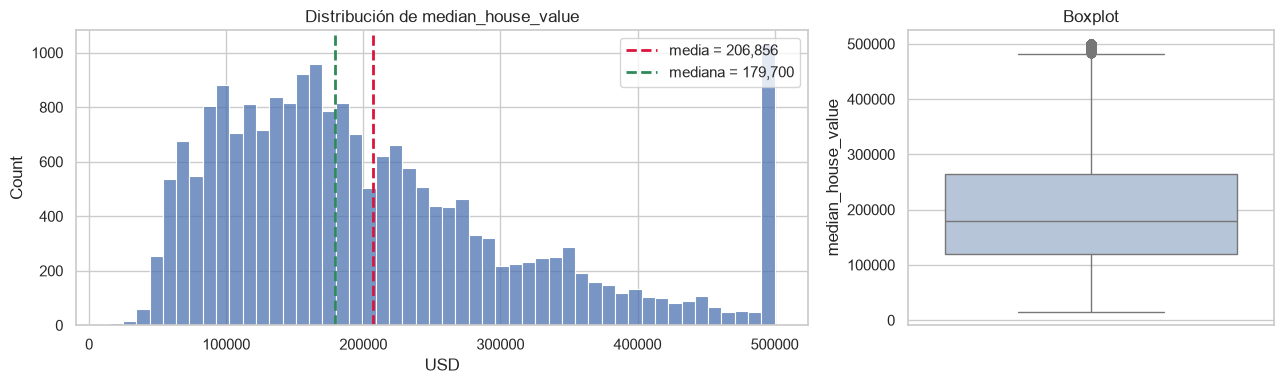

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4),
                               gridspec_kw={"width_ratios": [2, 1]})

sns.histplot(x, bins=50, ax=ax1)
ax1.axvline(x.mean(), color="crimson", ls="--", lw=2, label=f"media = {x.mean():,.0f}")
ax1.axvline(x.median(), color="seagreen", ls="--", lw=2, label=f"mediana = {x.median():,.0f}")
ax1.set_title("Distribución de median_house_value")
ax1.set_xlabel("USD")
ax1.legend()

sns.boxplot(y=x, ax=ax2, color="lightsteelblue")
ax2.set_title("Boxplot")

plt.tight_layout()
plt.show()

Ya lo veníamos viendo de reojo en las secciones anteriores, pero acá queda a la vista con
todo detalle: en el extremo derecho del histograma hay una **barra sola, altísima, pegada
al final**.

Esos son los 965 barrios topeados. En una distribución normal la cola se va apagando de a
poco; acá se apaga y de golpe reaparece un pico. **Un histograma delata un tope mejor que
cualquier tabla**: es una forma que no puede ocurrir naturalmente.

Y fijate en el boxplot de la derecha: esa misma masa de 965 registros aparece como una nube
de puntos sueltos arriba del bigote. El mismo problema, dibujado de dos maneras distintas.

#### ⚠️ Forzando el concepto (1): el mismo dato, tres historias

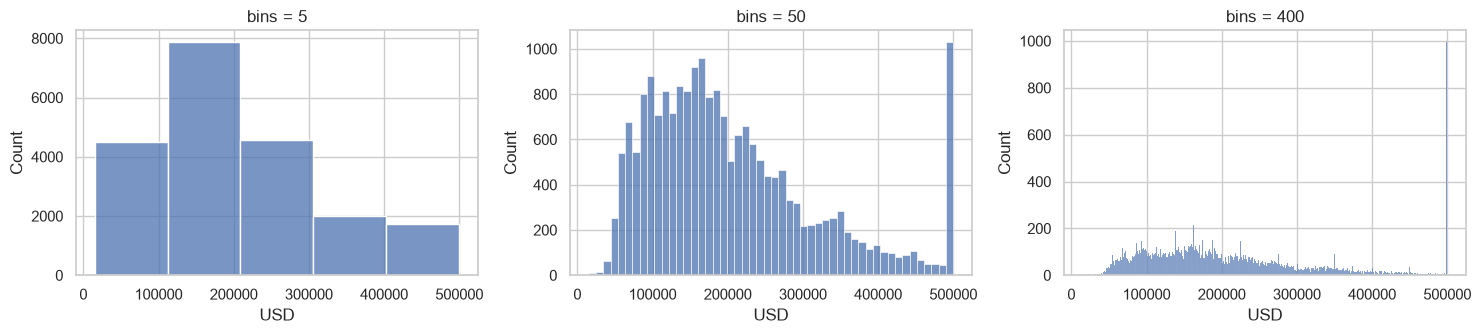

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, b in zip(axes, [5, 50, 400]):
    sns.histplot(x, bins=b, ax=ax)
    ax.set_title(f"bins = {b}")
    ax.set_xlabel("USD")
plt.tight_layout()
plt.show()

- Con **5 bins** el pico del tope desaparece: queda escondido dentro de la última barra
  ancha. **El problema de calidad se vuelve invisible.**
- Con **50** se ve la forma real y el pico salta a la vista.
- Con **400** el ruido empieza a competir con la señal.

> `bins` no es un detalle cosmético: con la elección equivocada, el hallazgo más
> importante del dataset se borra del gráfico. Probá varios antes de elegir.

#### ⚠️ Forzando el concepto (2): el 90% de los "atípicos" es el mismo problema

In [30]:
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
atipicos = x[(x < lim_inf) | (x > lim_sup)]
en_el_tope = (atipicos == x.max()).sum()

print(f"Límites de la regla 1,5·IQR: ({lim_inf:,.0f}, {lim_sup:,.0f})")
print(f"Marcados como atípicos     : {len(atipicos):,}  ({len(atipicos)/len(x):.1%})")
print(f"   ...de los cuales son el tope: {en_el_tope:,}  ({en_el_tope/len(atipicos):.0%})")

Límites de la regla 1,5·IQR: (-98,088, 482,412)
Marcados como atípicos     : 1,071  (5.2%)
   ...de los cuales son el tope: 965  (90%)


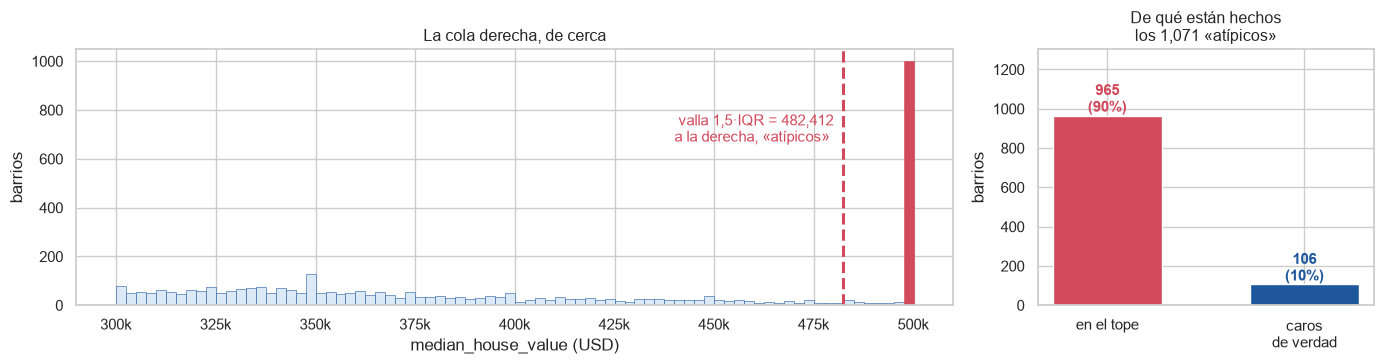

In [31]:
# Qué hay realmente del otro lado de la valla.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [3, 1.15]})

cola = x[x >= 300_000]
alturas, bordes, barras = a1.hist(cola, bins=80, color=AZUL_PALE, edgecolor=AZUL, lw=0.4)
barras[-1].set_facecolor(ROJO)        # la última barra es la del tope: 500.001
barras[-1].set_edgecolor(ROJO)
a1.axvline(lim_sup, color=ROJO, lw=2.2, ls="--")
a1.text(lim_sup - 2_500, a1.get_ylim()[1] * 0.75,
        f"valla 1,5·IQR = {lim_sup:,.0f}\na la derecha, «atípicos» ",
        fontsize=10.5, color=ROJO, va="top", ha="right")
a1.xaxis.set_major_formatter(en_miles)
a1.set_title("La cola derecha, de cerca", fontsize=11.5)
a1.set_xlabel("median_house_value (USD)")
a1.set_ylabel("barrios")

reales = len(atipicos) - en_el_tope
a2.bar(["en el tope", "caros\nde verdad"], [en_el_tope, reales], color=[ROJO, AZUL], width=0.55)
for i, v in enumerate([en_el_tope, reales]):
    a2.text(i, v + 20, f"{v:,}\n({v/len(atipicos):.0%})", ha="center", fontsize=11,
            fontweight="bold", color=[ROJO, AZUL][i])
a2.set_ylim(0, en_el_tope * 1.35)
a2.set_title(f"De qué están hechos\nlos {len(atipicos):,} «atípicos»", fontsize=11.5)
a2.set_ylabel("barrios")

plt.tight_layout()
plt.show()

De los 1.071 valores que el boxplot marca como atípicos, **965 son el tope**: el 90%.

No son 1.071 barrios excepcionalmente caros. Son 106 barrios caros y 965 registros
censurados. El boxplot no puede distinguir entre "valor extremo real" y "artefacto de
carga" — los dibuja igual.

> **"Atípico" no quiere decir "error", y tampoco quiere decir "real".** Quiere decir "lejos
> del centro según esta regla". Qué es cada punto lo tenés que averiguar vos.

### 4.3 · La foto por segmento: acá arranca la pregunta madre

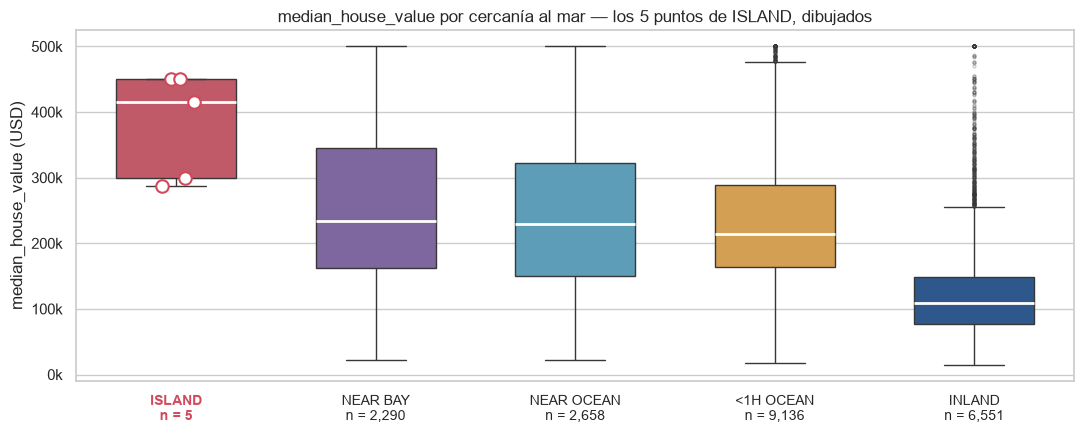

In [32]:
# Mapeo fijo de color por grupo: ISLAND siempre en rojo, para encontrarlo de un vistazo.
COLORES = {"INLAND": AZUL, "<1H OCEAN": "#E8A33D", "NEAR OCEAN": "#4FA3C7",
           "NEAR BAY": "#7B5EA7", "ISLAND": ROJO}
orden = df.groupby(GRUPO)[VALOR].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=df, x=GRUPO, y=VALOR, order=orden, hue=GRUPO, palette=COLORES,
            legend=False, width=0.6, ax=ax,
            medianprops={"color": "white", "lw": 2}, flierprops={"markersize": 2, "alpha": 0.25})

# Sólo ISLAND lleva sus puntos encima: son 5. Los otros grupos serían una mancha.
sns.stripplot(data=df[df[GRUPO] == "ISLAND"], x=GRUPO, y=VALOR, order=orden,
              color="white", edgecolor=ROJO, linewidth=1.5, s=9, ax=ax)

ax.set_xticks(range(len(orden)))
ax.set_xticklabels([f"{g}\nn = {(df[GRUPO] == g).sum():,}" for g in orden], fontsize=10)
for etiqueta, g in zip(ax.get_xticklabels(), orden):
    if g == "ISLAND":
        etiqueta.set_color(ROJO)
        etiqueta.set_fontweight("bold")

ax.yaxis.set_major_formatter(en_miles)
ax.set_xlabel("")
ax.set_ylabel("median_house_value (USD)")
ax.set_title("median_house_value por cercanía al mar — los 5 puntos de ISLAND, dibujados")
plt.tight_layout()
plt.show()

`INLAND` se ve claramente distinto del resto. Entre `NEAR BAY`, `NEAR OCEAN` y `<1H OCEAN`
las cajas se pisan casi por completo. Y `ISLAND` —la caja más alta— está dibujada con
**cinco puntos**.

**Acá se termina lo que la estadística descriptiva puede hacer.** El gráfico *insinúa* que
hay diferencias, pero no dice si son reales o si podrían haber salido por azar. Esa
pregunta —*¿la diferencia es real?*— es el punto 5.

---
## 5 · Lo que hay que llevarse del punto 2

1. **Media y mediana responden preguntas distintas.** Cuando se separan, hay una cola.
2. **Un problema de calidad puede cambiar la FORMA**, no sólo los números: el tope hizo que
   la distribución pareciera casi simétrica.
3. **La mediana es robusta siempre; la media es frágil sobre todo con `n` chico.**
4. **La varianza está en unidades al cuadrado**; por eso se reporta el desvío.
5. **`n−1` importa con muestras chicas y es irrelevante con muestras grandes.**
6. **El desvío no compara escalas distintas; el CV sí**